# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [9]:
%matplotlib inline

import os
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt
from abtem.visualize.artists import ScaleBar

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.8


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

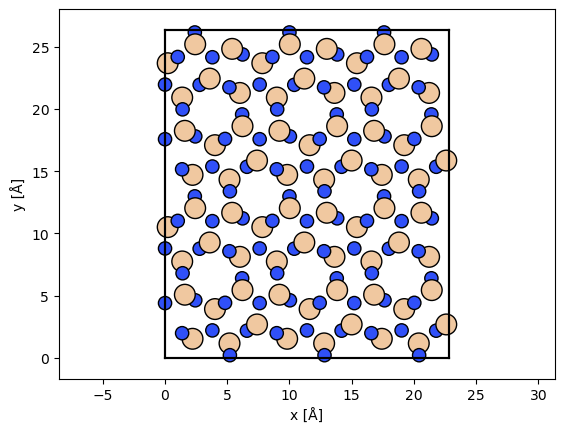

In [11]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
structure_orthogonal = abtem.atoms.orthogonalize_cell(structure)

output_dir = './figures'
os.makedirs(output_dir, exist_ok=True)

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
si3n4_fig, si3n4_axes = abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy')
si3n4_fig.savefig('./figures/Si3N4.png', dpi=300, bbox_inches='tight')

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

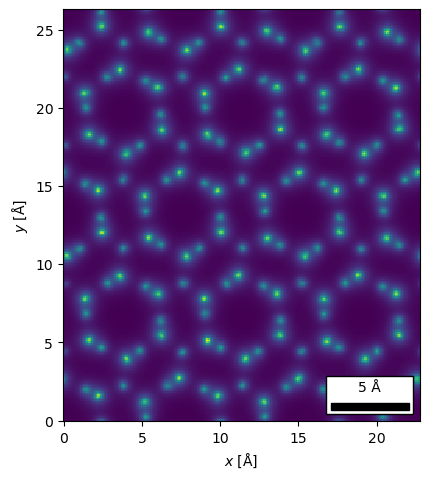

In [17]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},  # thermal displacement in Å
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,           # real-space sampling in Å/pixel
    slice_thickness=2.0,    # thickness of each projected slice in Å
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential_plot = potential.project().show(cmap='viridis')
potential_scalebar = ScaleBar(ax=potential_plot.axes.axes[0][0], label='5 Å', size=5, size_vertical=0.5, frameon=True)
potential_plot.get_figure().savefig('./figures/projected_potential.png', dpi=300, bbox_inches='tight')

---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

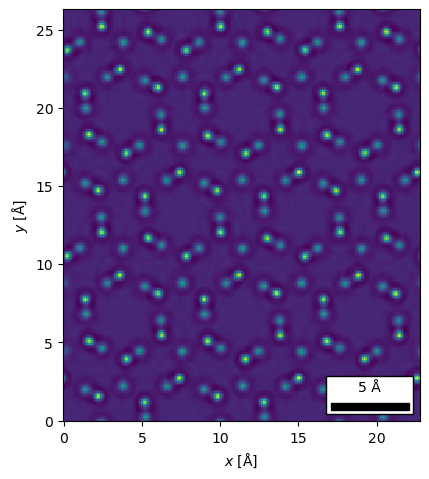

In [18]:
# TASK 2: Initialize the PlaneWave with 300 keV energy
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

# TASK 2: Run the multislice simulation
# This propagates the wave through each slice of the potential
exit_waves = wave.multislice(potential)

# TASK 2: Plot the mean intensity of the exit waves
# .intensity() computes |ψ|², .mean(0) averages over frozen phonon configs
exit_wave_plot = exit_waves.intensity().mean(0).show(cmap='viridis')
exit_wave_scalebar = ScaleBar(ax=exit_wave_plot.axes.axes[0][0], label='5 Å', size=5, size_vertical=0.5, frameon=True)
exit_wave_plot.get_figure().savefig('./figures/exit_waves.png', dpi=300, bbox_inches='tight')

---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

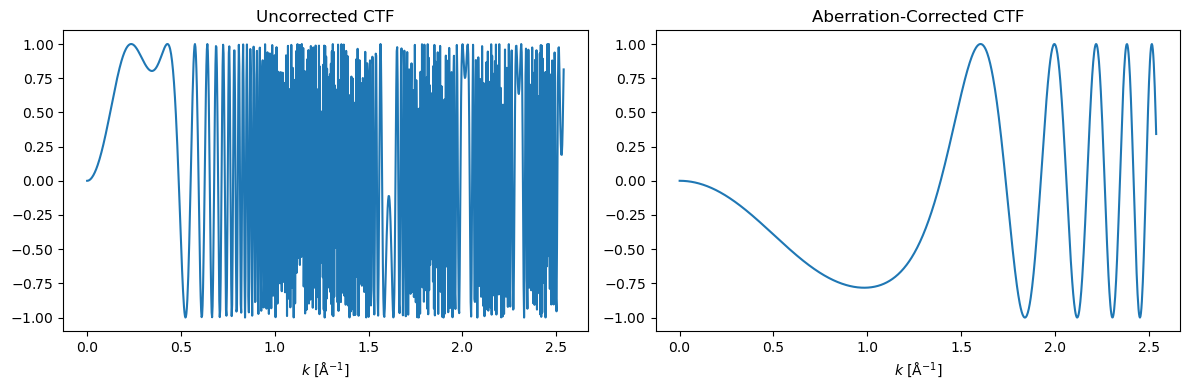

In [20]:
# TASK 3a: Define the UNCORRECTED CTF
# C10 = defocus (Δf) in Å  |  C30 = spherical aberration (Cs) in Å
# For a conventional 300 kV TEM: Cs ≈ 1.3 mm = 1.3e7 Å
parameters_uncorrected = {
    'C10': -600,        # defocus in Å  (negative = underfocus)
    'C30': 1.3e7,       # Cs in Å (1.3 mm)
}
ctf_uncorrected = abtem.transfer.CTF(energy=300e3, aberration_coefficients=parameters_uncorrected)

# TASK 3b: Define the ABERRATION-CORRECTED CTF
# In a Cs-corrected microscope, residual Cs is small and can be negative
parameters_corrected = {
    'C10': 30,          # small defocus in Å
    'C30': -8e4,        # small, negative residual Cs in Å
}
ctf_corrected = abtem.transfer.CTF(energy=300e3, aberration_coefficients=parameters_corrected)

# TASK 3c: Plot both CTFs to compare their spatial frequency transfer
# Hint: use ctf.show() on each CTF object
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ctf_uncorrected.profiles().show(ax=axes[0])
axes[0].set_title('Uncorrected CTF')
ctf_corrected.profiles().show(ax=axes[1])
axes[1].set_title('Aberration-Corrected CTF')
plt.tight_layout()
plt.show()
fig.savefig('./figures/CTF_comparison.png', dpi=300, bbox_inches='tight')

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

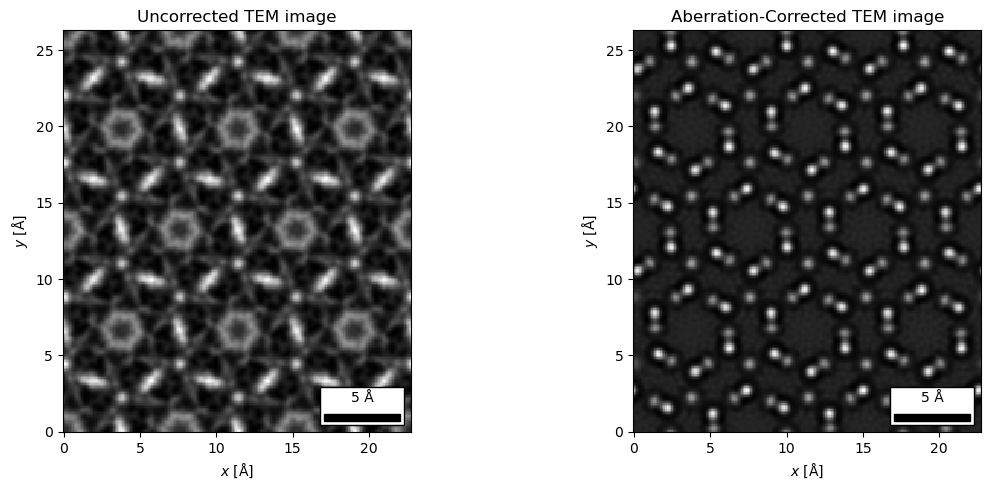

In [22]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='gray', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')
uncorrected_scalebar = ScaleBar(ax=axes[0], label='5 Å', size=5, size_vertical=0.5, frameon=True)

image_corrected.intensity().mean(0).show(cmap='gray', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')
corrected_scalebar = ScaleBar(ax=axes[1], label='5 Å', size=5, size_vertical=0.5, frameon=True)

plt.tight_layout()
plt.show()
fig.savefig('./figures/correction_comparison.png', dpi=300, bbox_inches='tight')

---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/33 [00:00<?, ?it/s]

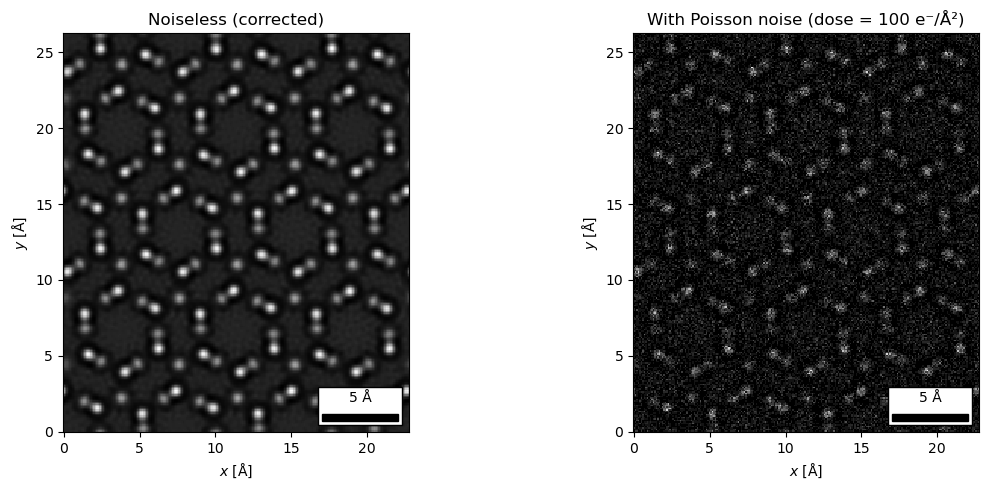

In [23]:
# TASK 4: Apply Poisson noise to the aberration-corrected image
# dose is in electrons per Å²; lower dose → more noise
dose = 100  # e⁻/Å²

# First get the noiseless mean intensity image, then add noise
noiseless_image = image_corrected.intensity().mean(0)
noisy_image = noiseless_image.poisson_noise(dose_per_area=dose)

# TASK 4: Plot the noiseless vs noisy images side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap='gray', ax=axes[0])
axes[0].set_title(f'Noiseless (corrected)')
noiseless_scalebar = ScaleBar(ax=axes[0], label='5 Å', size=5, size_vertical=0.5, frameon=True)

noisy_image.show(cmap='gray', ax=axes[1])
axes[1].set_title(f'With Poisson noise (dose = {dose} e⁻/Å²)')
noisy_scalebar = ScaleBar(ax=axes[1], label='5 Å', size=5, size_vertical=0.5, frameon=True)

plt.tight_layout()
plt.show()
fig.savefig('./figures/noise_comparison.png', dpi=300, bbox_inches='tight')

---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

**1. Contrast Transfer Function (CTF):**
*The uncorrected CTF is noisier and exhibits an onset of high-frequency oscillations at much lower spatial frequencies compared to the corrected CTF. This would thus explain why the aberration-corrected image shows sharper atomic columns; the onset of the "first zero" occurs at a higher spatial frequency and thus, a wider range of frequencies of the diffracted waves contribute to image formation. In real space terms, this means that the atomic columns can be imaged at a much higher resolution (recall that a high frequency in reciprocal space leads to shorter length scales in real space).*

**2. Defocus and Contrast:**
*Setting a defocus of zero would limit the range of spatial frequencies that the CTF will be nonzero due to spherical aberration. Implementing a Scherzer defocus to the CTF addresses this by artificially adding a defocus value to minimize the effects of spherical aberration. This effectively stretches out the CTF such that it can be nonzero across a wider range of spatial frequencies, which will then lead to an image with much higher spatial resolution.*

**3. Simulation vs. Reality:**
*Adding Poisson noise makes the final image a bit more difficult to interpret, as the atomic columns no longer have as much contrast (Si and N now both look equally bright) nor clarity (the atoms look grainier). This is similar to the noise that is present in real HRTEM images, which typically emerge as a result of poor signal intensity (which can be linked to experimental parameters like short dwell times or low electron dose), poor detector quality, or lattice vibrations (i.e. phonons).*

**4. Multislice Algorithm:**
*If a sample has a non-negligible thickness, the incoming electron beam will undergo multiple scattering events as it is being transmitted through the sample, in which case a kinematic approximation no longer suffices. Using a multislice method instead can account for these dynamical scattering events because it effectively keeps track of the projected potential as the beam continually becomes more perturbed across the sample thickness. Dividing up the sample into thinner pieces and iterating these projected potential calculations can more accurately capture the multiple scattering events that occur during imaging, which again a single projected potential across the entire sample thickness alone cannot.*